In [16]:
from herbie import Herbie

import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [17]:
# Download HRRR 2-meter temperature
H = Herbie('2026-07-30 12:00', model='rrfs', fxx=34,  
           member='control', domain='conus')

print(H.inventory(":APCP:"))

# Get unique variable abbreviations across all levels
print(H.inventory()['variable'].unique())

ds = H.xarray(":PWAT:")

✅ Found ┊ model=rrfs ┊ product=prslev ┊ 2026-Jul-30 12:00 UTC F34 ┊ GRIB2 @ aws ┊ IDX @ local
Empty DataFrame
Columns: [grib_message, start_byte, end_byte, range, reference_time, valid_time, variable, level, forecast_time, search_this]
Index: []
<StringArray>
[  'HGT',   'TMP',    'RH',   'DPT',  'SPFH',  'DZDT',  'UGRD',  'VGRD',
  'ABSV',  'CLMR',  'ICMR',  'RWMR',  'SNMR',  'GRLE',  'STRM', 'MCONV',
  'PRES',   'POT',  'PWAT',   'PLI']
Length: 20, dtype: str


fxx = Target UTC Time - Model Run UTC Time

Running model from every hour for short-term forecasting, 
or use 00:00, 06:00, 12:00, 18:00 UTC for 60-84 hours ahead forecasting.

E.x. Running from 12 PM today, July 30th, with a target time of 12pm or midnight EDT tomorrow night.

Get UTC time: 
July 30th, 12:00 (12pm EDT) + 4 hours = July 30th, 16:00 UTC
July 31st, 00:00 (Midnight EDT) + 4 hours = July 31st, 04:00 UTC

Get fxx value: (24 hours to noon on the 31st, plus 12 more)
July 30th, 16:00 UTC to July 31st 04:00 UTC = fxx = (24 + 12) =  36 hours 

In [18]:
# Extract variables for hourly accumulated precipitation
precip_mm = ds['pwat'].values
lons = ds.longitude
lats = ds.latitude

# Convert from mm to inches
precip_in = precip_mm / 25.4

print(precip_in)

[[0.23464568 0.23622048 0.23661418 ... 0.18661417 0.18700787 0.18700787]
 [0.23307087 0.23582676 0.23622048 ... 0.19015747 0.18858267 0.18700787]
 [0.23346457 0.23543307 0.23543307 ... 0.19251968 0.19133858 0.18779528]
 ...
 [0.09015748 0.09015748 0.08976378 ... 0.13622047 0.13622047 0.13622047]
 [0.08976378 0.08818898 0.08818898 ... 0.13622047 0.13622047 0.13622047]
 [0.08818898 0.08700788 0.08661418 ... 0.13622047 0.13622047 0.13622047]]


In [19]:
# Mask out 0 mm rain so the background doesn't go all weird colors
precip_in = np.ma.masked_where(precip_in < 0.05, precip_in)

# Midwest Extent Box [W, E, S, N]
midwest_extent = [-105, -80, 36, 49]

print("Min PWAT (inches):", float(precip_in.min()))
print("Max PWAT (inches):", float(precip_in.max()))

Min PWAT (inches): 0.05000000074505806
Max PWAT (inches): 0.33543309569358826


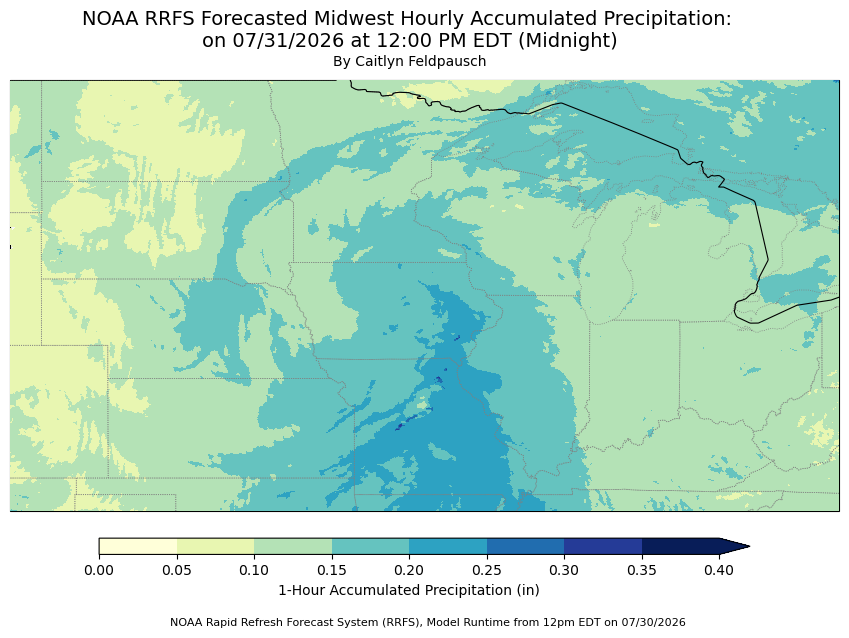

In [20]:
# Precip map for july 31st at 6pm EDT

# Create Figure
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(midwest_extent, crs=ccrs.PlateCarree())

# Add Geographic Features
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue', zorder=1)
ax.add_feature(cfeature.LAND, facecolor='whitesmoke', zorder=1)
ax.add_feature(cfeature.LAKES, facecolor='aliceblue', edgecolor='gray', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.add_feature(
    cfeature.STATES, edgecolor='gray', linestyle=':', linewidth=0.6, zorder=5
)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, zorder=6)

# Define Discrete Color Levels for Precipitation (in mm)
# Adjust bounds as needed depending on light vs. heavy event expectations
levels = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
cmap = plt.get_cmap('YlGnBu')
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)

# Plot Precipitation
mesh = ax.pcolormesh(
    lons,
    lats,
    precip_in,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    zorder=3,)

# Colorbar and Labels
cbar = plt.colorbar(mesh, label='1-Hour Accumulated Precipitation (in)', orientation='horizontal',
    pad=0.05, shrink=0.7, aspect=40, extend='max',)

# Set Titles based on forecast dataset attributes
valid_time_str = str(ds.valid_time.values)[:16]

plt.suptitle(f"NOAA RRFS Forecasted Midwest Hourly Accumulated Precipitation: \non 07/31/2026 at 12:00 PM EDT (Midnight)", fontsize=14)

fig.text(0.30, 0.10, "NOAA Rapid Refresh Forecast System (RRFS), Model Runtime from 12pm EDT on 07/30/2026", fontsize=8)
fig.text(0.5, 0.90, 'By Caitlyn Feldpausch', ha='center', fontsize=10)

fig.savefig('RRFS_CONUS_Precipitation.png', dpi=300, bbox_inches='tight')
plt.show()

# For subplots:

# FLorida Box [W,E,S,N]
fig_extent = [-88, -79, 24, 32]

# Artemis I 2m Air Temp Map
# Create blank subplots with sizing, projection
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8), constrained_layout=True, 
                               subplot_kw={'projection': ccrs.PlateCarree()})

# Apply the extent to the first subplot
ax1.set_extent(fig_extent, crs=ccrs.PlateCarree())
ax2.set_extent(fig_extent, crs=ccrs.PlateCarree())

# Plot temperature 
mesh1 = ax1.pcolormesh(ds1.longitude, ds1.latitude, temp1_f, 
                       transform=ccrs.PlateCarree(), cmap='RdYlBu_r', vmin=0,  vmax=95, zorder=1)
mesh2 = ax2.pcolormesh(ds2.longitude, ds2.latitude, temp2_f, 
                       transform=ccrs.PlateCarree(), cmap='RdYlBu_r', vmin=0,  vmax=95, zorder=1)

# Add Coastline, States, Borders, Lakes, Oceans
ax1.add_feature(cfeature.COASTLINE, zorder=4)
ax1.add_feature(cfeature.STATES, edgecolor='gray', zorder=5)
ax1.add_feature(cfeature.BORDERS, linestyle=':', zorder=6)
ax1.add_feature(cfeature.LAKES, facecolor='lightblue', edgecolor='gray', zorder=3)
ax1.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=2)
ax2.add_feature(cfeature.COASTLINE, zorder=4)
ax2.add_feature(cfeature.STATES, edgecolor='gray', zorder=5)
ax2.add_feature(cfeature.BORDERS, linestyle=':', zorder=6)
ax2.add_feature(cfeature.LAKES, facecolor='lightblue', edgecolor='gray', zorder=3)
ax2.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=2)

# Plot cities with white text box labels, including KSC
for city, coord in cities.items():
    # SKIP KSC to prevent double labeling
    if city == "Kennedy Space Center":
        continue
    # Pull the specific Artemis I temperature from our dictionary
    city_val = round(city_temps[city]["Artemis I"])
    
    # Combine City Name and Temperature for the label
    label_text = f"{city}\n{city_val}°F"
    
    ax1.text(coord[1] + 0.1, coord[0] + 0.1, label_text, 
             transform=ccrs.PlateCarree(), fontsize=8, color='black', zorder=20, 
             bbox=dict(facecolor='white', edgecolor='black', alpha=0.9, boxstyle='round,pad=0.3'))
    
    ax1.scatter(coord[1], coord[0], color='white', edgecolor='black', 
                marker='o', s=40, transform=ccrs.PlateCarree(), zorder=21)

for city, coord in cities.items():
    # SKIP KSC to prevent double labeling
    if city == "Kennedy Space Center":
        continue
    # Pull the specific Artemis I temperature from our dictionary
    city_val = round(city_temps[city]["Artemis II"])
    
    # Combine City Name and Temperature for the label
    label_text = f"{city}\n{city_val}°F"
    
    ax2.text(coord[1] + 0.1, coord[0] + 0.1, label_text, 
             transform=ccrs.PlateCarree(), fontsize=8, color='black', zorder=20, 
             bbox=dict(facecolor='white', edgecolor='black', alpha=0.9, boxstyle='round,pad=0.3'))
    
    ax2.scatter(coord[1], coord[0], color='white', edgecolor='black', 
                marker='o', s=40, transform=ccrs.PlateCarree(), zorder=21)
    
# Plot launch site at KSC
ax1.scatter((cities["Kennedy Space Center"][1]), (cities["Kennedy Space Center"][0]), color='white', marker='*', s=450, 
            edgecolor='black', transform=ccrs.PlateCarree(), zorder=25)
ax1.text((cities["Kennedy Space Center"][1]) + 0.4, (cities["Kennedy Space Center"][0]) + 0.3, f'Kennedy\nSpace\nCenter\n{round(city_temps["Kennedy Space Center"]["Artemis I"])}°F', 
         transform=ccrs.PlateCarree(), fontweight='bold', fontsize=10, color='black', verticalalignment='center', zorder=26)
ax2.scatter((cities["Kennedy Space Center"][1]), (cities["Kennedy Space Center"][0]), color='white', marker='*', s=450, 
            edgecolor='black', transform=ccrs.PlateCarree(), zorder=25)
ax2.text((cities["Kennedy Space Center"][1]) + 0.4, (cities["Kennedy Space Center"][0]) + 0.3, f'Kennedy\nSpace\nCenter\n{round(city_temps["Kennedy Space Center"]["Artemis I"])}°F', 
         transform=ccrs.PlateCarree(), fontweight='bold', fontsize=10, color='black', verticalalignment='center', zorder=26)


ax1.set_title(f"Artemis I: 11/16/2022 at 1:47 AM EST", fontsize=14)
ax2.set_title(f"Artemis II: 04/01/2026 at 6:24 PM EST", fontsize=14)
cbar = plt.colorbar(mesh1, ax=[ax1,ax2], label='2m Temperature (°F)', location='right', orientation='vertical', extend='max', pad=0.02, shrink=0.6, aspect=50)
cbar.ax.tick_params(labelsize=12)

# Add a global X-label centered at the bottom, author
fig.text(0.47, 0.05, 'NOAA High-Resolution Rapid Refresh (HRRR)', ha='center', fontsize=10)
fig.text(0.47, 0.93, 'By Caitlyn Feldpausch', ha='center', fontsize=12)
fig.suptitle('2m Surface Air Temperature at the Kennedy Space Center Launch Site', fontsize=16)
    
#plt.tight_layout()
plt.show()

fig.savefig('Artemis1-2-2m-AirTemp-Subplots.png', dpi=300, bbox_inches='tight')